In [1]:
import duckdb, pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DB_PATH = ROOT / "data" / "olist.db"
con = duckdb.connect(str(DB_PATH))
print("Connected:", DB_PATH)

Connected: /Users/user/Desktop/data-science-projects/Marketplace-Incentives-Causal-Inference/data/olist.db


In [8]:
orders_treated_columns = con.sql("SELECT * FROM orders_treated LIMIT 1").df().columns.tolist()
orders_treated_columns

['order_id',
 'customer_id',
 'customer_state',
 'purchase_ts',
 'purchase_date',
 'purchase_month',
 'order_status',
 'delivered_customer_ts',
 'estimated_delivery_date',
 'n_items',
 'n_sellers',
 'gross_revenue',
 'freight_total',
 'payment_total',
 'n_payments',
 'review_score',
 'is_delivered',
 'delivery_days',
 'on_time',
 'treated_region',
 'post',
 'incentive_flag']

In [55]:
twobytwo = con.sql("""
    SELECT post, treated_region, COUNT(*) AS n, AVG(on_time) AS mean_on_time
    FROM orders_treated
    WHERE is_delivered = True
    GROUP BY 1, 2
    ORDER BY 1, 2

""").df()
twobytwo


,post,treated_region,n,mean_on_time
0,0,0,3963,0.951540
1,0,1,7102,0.964095
2,1,0,28310,0.911409
3,1,1,57103,0.937316


In [32]:
pivot = twobytwo.pivot(index="treated_region", columns="post", values="mean_on_time")
pivot.columns = ["pre", "post"]
pivot.index = ["control", "treated"]
pivot

,pre,post
control,0.951540,0.911409
treated,0.964095,0.937316


In [46]:
T_pre = pivot.loc["treated", "pre"]
T_post = pivot.loc["treated", "post"]
C_post = pivot.loc["control", "post"]
C_pre = pivot.loc["control", "pre"]
did_hand = (T_post - T_pre) - (C_post - C_pre)
print(f"Treated:  pre={T_pre:.3f}  post={T_post:.3f}")
print(f"Control:  pre={C_pre:.3f}  post={C_post:.3f}")
print(f"DiD (hand): {did_hand:.3f}")



Treated:  pre=0.964  post=0.937
Control:  pre=0.952  post=0.911
DiD (hand): 0.013


In [53]:
df = con.sql("""
SELECT on_time, treated_region, post
FROM orders_treated
WHERE is_delivered = TRUE
""").df()

df["on_time"] = df["on_time"].astype(float)
df["treated_region"] = df["treated_region"].astype(int)

model = smf.ols("on_time ~ treated_region * post", data=df).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                on_time   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     118.9
Date:                Sat, 27 Jun 2026   Prob (F-statistic):           7.55e-77
Time:                        14:13:46   Log-Likelihood:                -3465.2
No. Observations:               96470   AIC:                             6938.
Df Residuals:                   96466   BIC:                             6976.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.9515      0.004    238.788      0.000       0.944       0.959
treated_region          0.0126      0.005      2.524      0.012       0.003       0.022
post                   -0.0401      0.004     -9.432      0.000      -0.048      -0.032
treated_region:post     0.0134      0.005      2.520      0.012       0.003       0.024
==============================================================================
Omnibus:                    65610.451   Durbin-Watson:                   1.994
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           571382.971
Skew:                          -3.421   Prob(JB):                         0.00
Kurtosis:                      12.764   Cond. No.                         18.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Step A — DiD point estimate

The 2×2 table and regression above estimate **τ̂**, the difference-in-differences effect of the simulated regional rollout on on-time delivery rate (delivered orders only).

**Hand DiD and the `treated_region:post` interaction coefficient agree (~+0.013).** That is the estimand: treated states saw roughly **1.3 percentage points less decline** in on-time rate after June 2017 than control states, relative to their pre-period baselines. Both arms still fell — control dropped ~4 pp, treated ~2.7 pp — so this is a *relative* improvement, not proof that treated states got better in absolute terms.

**How to read the regression (not all coefficients are τ):**
- **Intercept** → control-group pre-period mean (baseline).
- **treated_region** → pre-period level gap between arms (δ from state infrastructure **W**). DiD removes this automatically; it is not the causal effect.
- **post** → how much control changed from pre to post (platform-wide time trend λ in the control arm).
- **treated_region:post** → **τ̂** — the extra change for treated vs control after the cutoff.

We use OLS on a binary outcome (linear probability model) so the interaction is directly in probability points and matches the hand calculation. R² ≈ 0.004 is fine here: we are not predicting individual orders, we are estimating a group-period contrast.

**Honesty line:** This is a simulated quasi-experiment on observational data, not a randomized A/B test. τ̂ is only interpretable as a causal effect if parallel trends held — checked in Step B below.

## Step B — Parallel trends

DiD assumes both arms would have followed the same trajectory absent the rollout. We check pre-cutoff monthly on-time rates. Stable gap + similar slopes = supporting evidence; diverging slopes = red flag for **S** (seasonality) or **C** (composition).

In [57]:
con.sql("SELECT * FROM orders_treated LIMIT 1").df()

,order_id,customer_id,customer_state,purchase_ts,purchase_date,purchase_month,order_status,delivered_customer_ts,estimated_delivery_date,n_items,...,freight_total,payment_total,n_payments,review_score,is_delivered,delivery_days,on_time,treated_region,post,incentive_flag
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,SP,2017-10-02 10:56:33,2017-10-02,2017-10-01,delivered,2017-10-10 21:25:13,2017-10-18,1,...,8.72,38.71,3,4.0,True,8,1,1,1,1


In [66]:
CUTOFF = pd.Timestamp("2017-06-01")
monthly = con.sql("""
    SELECT purchase_month, 
    CASE WHEN treated_region = 1 THEN 'treated' ELSE 'control' END AS arm, 
    COUNT(*) AS n,
    ROUND(AVG(on_time), 3) AS on_time_rate
    FROM orders_treated
    WHERE is_delivered = TRUE 
    GROUP BY 1, 2
    ORDER BY 1, 2; 
""").df()
monthly["purchase_month"] = pd.to_datetime(monthly["purchase_month"])
monthly.head(5)

,purchase_month,arm,n,on_time_rate
0,2016-09-01,treated,1,0.000
1,2016-10-01,control,96,1.000
2,2016-10-01,treated,169,0.988
3,2016-12-01,control,1,1.000
4,2017-01-01,control,274,0.960


### Full-window plot — readout

**Context, not proof:** Post-cutoff, both arms fall — consistent with Step A (platform-wide decline ~4 pp control, ~2.7 pp treated). Treated stays modestly above control early post-period, matching positive τ̂. The large synchronized drop around late 2017 hits **both** arms → likely a common shock (**S**), not something DiD attributes to the simulated rollout alone.

**Important:** You cannot validate parallel trends from the post period (no counterfactual treated trend). This plot explains *what happened* after June 2017; the pre-only plot is what supports (or weakens) the causal story.

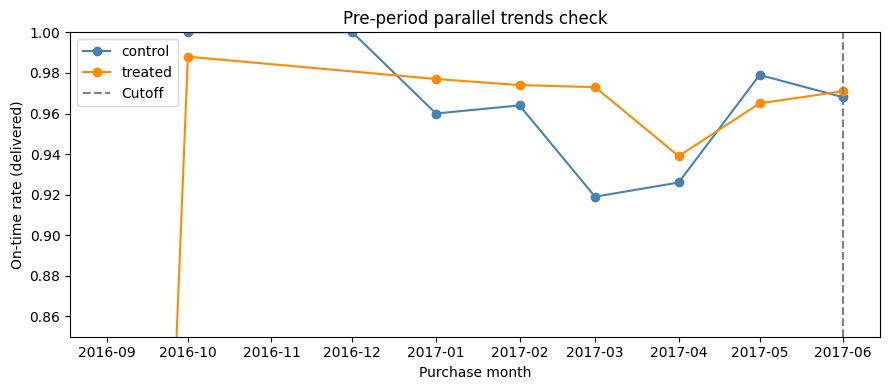

In [70]:
fig, ax = plt.subplots(figsize=(9, 4))
pre = monthly[monthly["purchase_month"] <= CUTOFF]
for arm, color in [("control", "steelblue"), ("treated", "darkorange")]:
    d = pre[pre["arm"] == arm].sort_values("purchase_month")
    ax.plot(d["purchase_month"], d["on_time_rate"], marker="o", label=arm, color=color)
ax.axvline(CUTOFF, color="gray", linestyle="--", linewidth=1.5, label="Cutoff")
ax.set_title("Pre-period parallel trends check")
ax.set_ylabel("On-time rate (delivered)")
ax.set_xlabel("Purchase month")
ax.set_ylim(0.85, 1.0)
ax.legend()
plt.tight_layout()
plt.show()

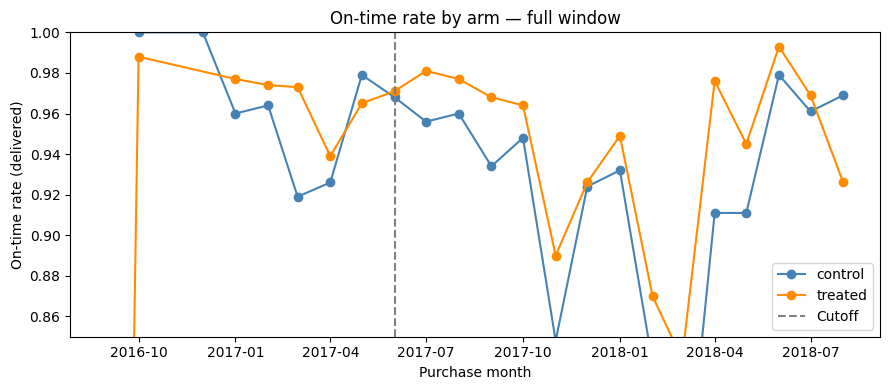

In [67]:
fig, ax = plt.subplots(figsize=(9, 4))
for arm, color in [("control", "steelblue"), ("treated", "darkorange")]:
    d = monthly[monthly["arm"] == arm].sort_values("purchase_month")
    ax.plot(d["purchase_month"], d["on_time_rate"], marker="o", label=arm, color=color)
ax.axvline(CUTOFF, color="gray", linestyle="--", linewidth=1.5, label="Cutoff")
ax.set_title("On-time rate by arm — full window")
ax.set_ylabel("On-time rate (delivered)")
ax.set_xlabel("Purchase month")
ax.set_ylim(0.85, 1.0)
ax.legend()
plt.tight_layout()
plt.show()

### Pre-period plot — readout

This is the core parallel-trends diagnostic: would treated and control have kept moving together without the simulated rollout?

**What we see:** Treated (orange) runs slightly above control (blue) most months — that is a **level gap (δ)**, not a violation; DiD differences levels out. **Slopes are shaky:** control drops sharply around Jan–Mar 2017 while treated is flatter, then both converge near the cutoff. Some months have tiny **n** (e.g. Sep 2016 treated n=1), so wiggles may be noise.

**Call:** **Partially plausible, not clean.** Pre-period trajectories are not perfectly parallel, but there is no obvious sustained divergence in one direction either. I would not claim parallel trends is proven — only that the plot does not scream obvious pre-trend violation. τ̂ = +0.013 should be reported with this caveat (**S** seasonality / platform shocks may affect arms differently in thin months).

## Step C — Bootstrap 95% CI

Resampling unit: **orders** (with replacement). Quantifies uncertainty on τ̂ without relying solely on OLS standard errors.

In [79]:
def did_estimate(data, cutoff = None):
    """Hand DiD. Pass cutoff='2017-06-01' to redefine post (Step D)."""
    d = data.copy()
    if cutoff is not None:
        d["post"] = (pd.to_datetime(d["purchase_date"]) >= pd.Timestamp(cutoff)).astype(int)
    means = d.groupby(["treated_region", "post"])["on_time"].mean().unstack()
    return (means.loc[1, 1] - means.loc[1, 0]) - (means.loc[0, 1] - means.loc[0, 0])

df_boot = con.sql("""
SELECT on_time, treated_region, post, purchase_date
FROM orders_treated
WHERE is_delivered = TRUE
""").df()

df_boot["on_time"] = df_boot["on_time"].astype(float)
df_boot["treated_region"] = df_boot["treated_region"].astype(int)
df_boot["post"] = df_boot["post"].astype(int)

point_est = did_estimate(df_boot)
print(f"Point estimate (should ≈ did_hand): {point_est:.4f}")

Point estimate (should ≈ did_hand): 0.0134


In [ ]:
N_BOOT = 1000
rng = np.random.default_rng(42)
boot_dids = []

for _ in range(N_BOOT):
    sample = df_boot.sample(n=len(df_boot), replace = True, randon_state =rng)
    boot_dids.append(did_estimate(sample))

boot_dids = np.array(boot_dids)
ci_low, ci_high = np.percentile(boot_dids, [2.5, 97.5])
print(f"Point estimate:  {point_est:.4f}  ({point_est*100:.2f} pp)")
print(f"Bootstrap mean:  {boot_dids.mean():.4f}")
print(f"95% CI:          [{ci_low:.4f}, {ci_high:.4f}]  ([{ci_low*100:.2f}, {ci_high*100:.2f}] pp)")
print(f"CI excludes 0?   {not (ci_low <= 0 <= ci_high)}")
    

Point estimate:  0.0134  (1.34 pp)
Bootstrap mean:  0.0133
95% CI:          [0.0040, 0.0217]  ([0.40, 2.17] pp)
CI excludes 0?   True


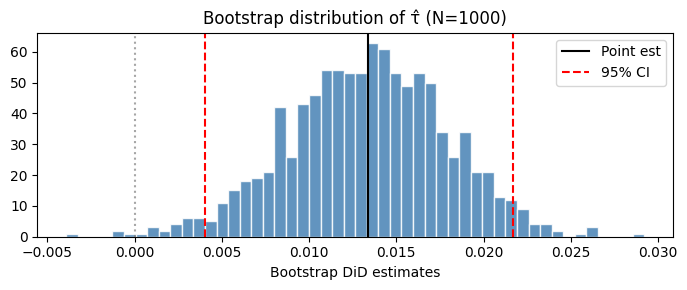

In [87]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(boot_dids, bins=50, color="steelblue", alpha=0.85, edgecolor="white")
ax.axvline(point_est, color="black", linewidth=1.5, label="Point est")
ax.axvline(ci_low, color="red", linestyle="--", label="95% CI")
ax.axvline(ci_high, color="red", linestyle="--")
ax.axvline(0, color="gray", linestyle=":", alpha=0.7)
ax.set_xlabel("Bootstrap DiD estimates")
ax.set_title(f"Bootstrap distribution of τ̂ (N={N_BOOT})")
ax.legend()
plt.tight_layout()
plt.show()

### Bootstrap interpretation

We estimate the simulated regional rollout increased on-time rate by **1.34 pp** (95% CI: **[0.40, 2.17] pp**), resampling **orders** with replacement (N=1,000).

The CI excludes zero, so the positive DiD is distinguishable from sampling noise at the 95% level — **conditional on parallel trends holding**. This is not proof the incentive caused the improvement; it means we are reasonably confident the treated–control *gap in changes* is not just random order-level noise.

Bootstrap CI aligns with OLS (interaction 95% CI ≈ [0.3, 2.4] pp). Both assume orders are independent; orders within the same state may be correlated (**W**), so a cluster bootstrap by `customer_state` would likely widen the interval (conservative stretch).

In [88]:
cutoffs = ["2017-05-18", "2017-05-25", "2017-06-01", "2017-06-08", "2017-06-15"]
sensitivity = []
for c in cutoffs:
    sensitivity.append({"cutoff": c, "did_estimate": did_estimate(df_boot, cutoff=c)})
sensitivity_df = pd.DataFrame(sensitivity)
sensitivity_df["did_pp"] = (sensitivity_df["did_estimate"] * 100).round(2)
sensitivity_df

,cutoff,did_estimate,did_pp
0,2017-05-18,0.008812,0.88
1,2017-05-25,0.011534,1.15
2,2017-06-01,0.013352,1.34
3,2017-06-08,0.013802,1.38
4,2017-06-15,0.015137,1.51


### Cutoff sensitivity

τ̂ ranges from **0.88 pp** to **1.51 pp** across cutoffs ±14 days from 2017-06-01. All estimates stay **positive** and the same order of magnitude (base 1.34 pp).

**Stable** — the result is not an artifact of picking one arbitrary date. Shifting the post-period start by two weeks does not flip the sign or blow up the estimate. That supports trusting the direction of τ̂, though magnitude still depends on exactly where summer volume and seasonality (**S**) land.

## Limitations

1. **Simulated quasi-experiment, not randomization.** Treatment is a fictional regional rollout applied to observational Olist data. We did not run an A/B test; SP/RJ/MG were not randomly assigned to receive an incentive.

2. **Parallel trends is assumed, not proven.** Pre-period monthly plots are supporting evidence only. Control was more volatile than treated in early 2017 (especially Jan–Mar), and some months have very small cell sizes — we call trends *partially plausible*, not clean. Post-cutoff divergence cannot validate the assumption (no untreated treated counterfactual).

3. **Short pre-period (~8 months).** Limited pre-trend history increases uncertainty about whether λ_treated = λ_control would have held beyond the cutoff.

4. **Backdoor paths from the Week 2 DAG.**
   - **S (seasonality):** Platform-wide shocks (e.g. late-2017 drop in both arms) affect interpretation — DiD attributes relative changes to the rollout, not absolute levels.
   - **W (state infrastructure):** Level gaps between arms (treated ~1–2 pp higher pre-cutoff) are expected; DiD differences out time-invariant δ if the assumption holds. RJ (~88% on-time) vs SP/MG (~95%) means τ̂ is a weighted average across heterogeneous treated states.
   - **C (order composition):** Shifts in order mix (`n_items`, `freight_total`) over time could bias DiD if arms diverge in composition pre-cutoff.

5. **Uncertainty quantification.** Bootstrap resamples **orders** with replacement (N=1,000). Orders within the same state may be correlated; i.i.d. resampling may yield **optimistic** CIs. Cluster bootstrap by `customer_state` would be more conservative (stretch).

6. **Outcome scope.** Analysis uses **delivered orders only**; `on_time` is undefined for non-delivered orders. We estimate an on-time rate among fulfilled orders, not overall order success.

7. **Magnitude vs certainty.** τ̂ ≈ **+1.3 pp** is modest. Bootstrap 95% CI **[0.4, 2.2] pp** excludes zero, but the effect is small in business terms and causal claims still depend on untestable identification assumptions.

8. **Next step.** A prospective randomized experiment (Week 4) would address what this observational DiD cannot: unbiased assignment, pre-specified metrics, and power to detect a policy-relevant effect size.